# Data & Imports

In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import kagglehub
from kagglehub import KaggleDatasetAdapter

In [20]:
file_path = "Walmart_Sales.csv"

df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "mikhail1681/walmart-sales",
  file_path,
)

df.to_csv('./data/Wallmart_Sales.csv', index=False)
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [21]:
df.drop_duplicates()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106
...,...,...,...,...,...,...,...,...
6430,45,28-09-2012,713173.95,0,64.88,3.997,192.013558,8.684
6431,45,05-10-2012,733455.07,0,64.89,3.985,192.170412,8.667
6432,45,12-10-2012,734464.36,0,54.47,4.000,192.327265,8.667
6433,45,19-10-2012,718125.53,0,56.47,3.969,192.330854,8.667


# Data Cleaning

In [22]:
df['Date'] = pd.to_datetime(df['Date'],format="%d-%m-%Y")

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week.astype(int)
df['Quarter'] = df['Date'].dt.quarter


df.drop('Date',axis=1, inplace=True)

In [23]:
df= df[['Year', 'Month','Week','Quarter','Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Weekly_Sales']]

In [24]:
df.head()

,Year,Month,Week,Quarter,Store,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Weekly_Sales
0,2010,2,5,1,1,0,42.31,2.572,211.096358,8.106,1643690.90
1,2010,2,6,1,1,1,38.51,2.548,211.242170,8.106,1641957.44
2,2010,2,7,1,1,0,39.93,2.514,211.289143,8.106,1611968.17
3,2010,2,8,1,1,0,46.63,2.561,211.319643,8.106,1409727.59
4,2010,3,9,1,1,0,46.50,2.625,211.350143,8.106,1554806.68


### Save Cleaned data copy

In [25]:
df.to_csv("./data/Wallmart_Sales_Cleaned.csv",index=False)

# EDA


### Weekly Sales Distribution

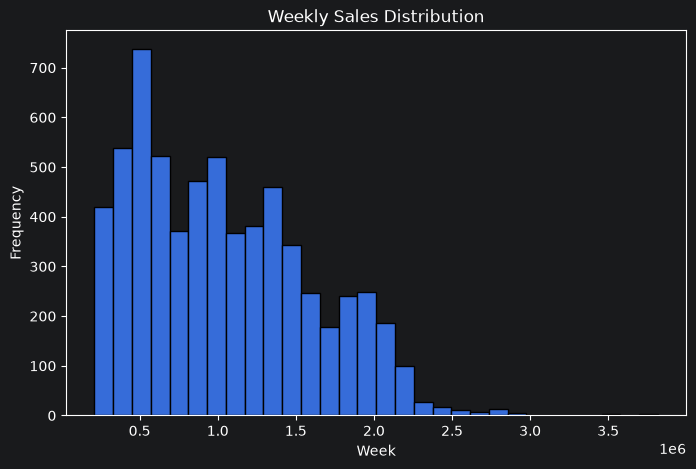

In [26]:
plt.figure(figsize=(8,5))
plt.hist(df['Weekly_Sales'],bins=30, edgecolor='black')
plt.xlabel('Week')
plt.ylabel('Frequency')
plt.title('Weekly Sales Distribution')
plt.savefig("images/weekly_sales_distribution.png",dpi=300,bbox_inches='tight')
plt.show()

### Boxplot (Outliers)

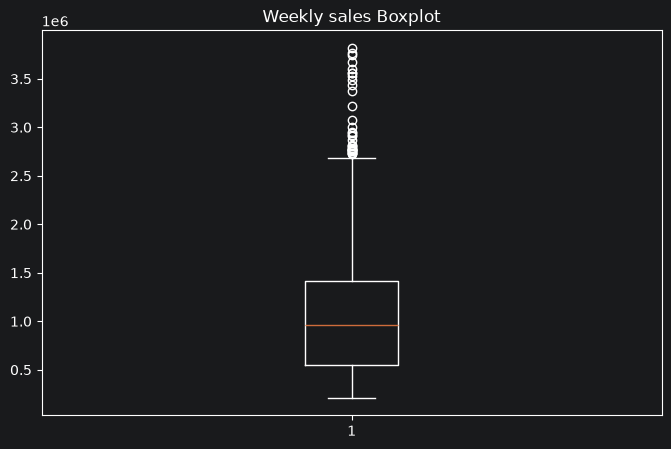

In [27]:
plt.figure(figsize=(8,5))
plt.boxplot(df["Weekly_Sales"])
plt.title('Weekly sales Boxplot')
plt.savefig("images/Weekly_sales_Boxplot.png",dpi=300,bbox_inches='tight')
plt.show()

### Temperature vs Weekly Sales

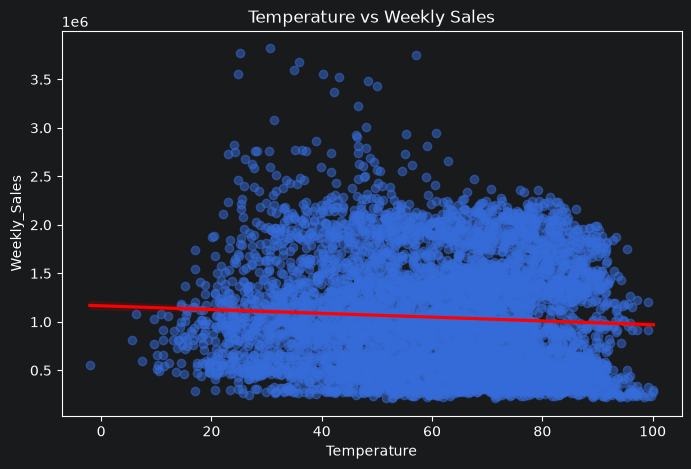

In [28]:
plt.figure(figsize=(8,5))
sns.regplot(
    data = df,
    x = 'Temperature',
    y = 'Weekly_Sales',
    scatter_kws={'alpha':0.5},
    line_kws= {'color':'red'}
)
plt.title('Temperature vs Weekly Sales')
plt.savefig("images/Temperature_vs_Weekly_Sales.png",dpi=300,bbox_inches='tight')
plt.show()

### Fuel Price vs Weekly Sales

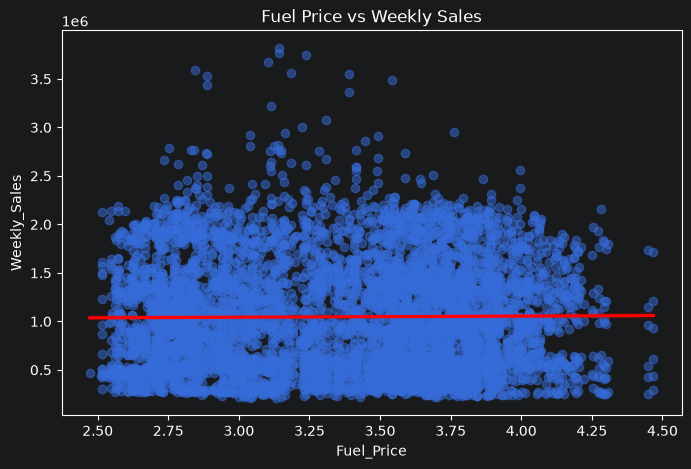

In [29]:
plt.figure(figsize=(8,5))

sns.regplot(
    data = df,
    x = 'Fuel_Price',
    y = 'Weekly_Sales',
    scatter_kws={'alpha':0.5},
    line_kws= {'color':'red'}
)
plt.title('Fuel Price vs Weekly Sales')

plt.savefig("images/Fuel_Price_vs_Weekly_Sales.png",dpi=300,bbox_inches='tight')
plt.show()

### CPI vs Weekly Sales

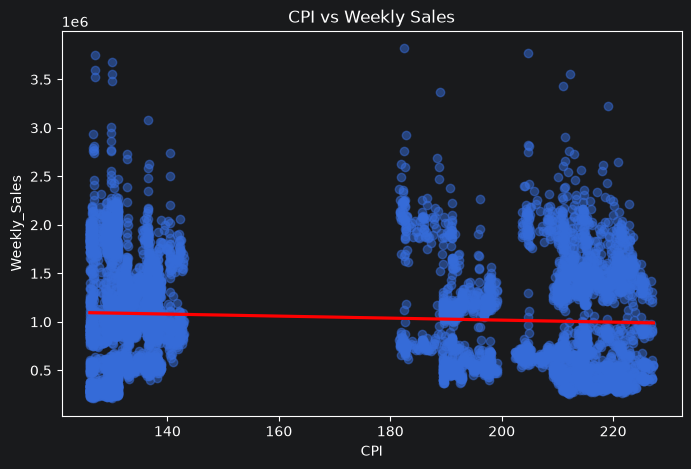

In [30]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data = df,
    x = 'CPI',
    y = 'Weekly_Sales',
    scatter_kws={'alpha':0.5},
    line_kws= {'color':'red'}
)
plt.title('CPI vs Weekly Sales')
plt.savefig("images/CPI_vs_Weekly_Sales.png",dpi=300,bbox_inches='tight')
plt.show()

### Unemployment vs Weekly Sales

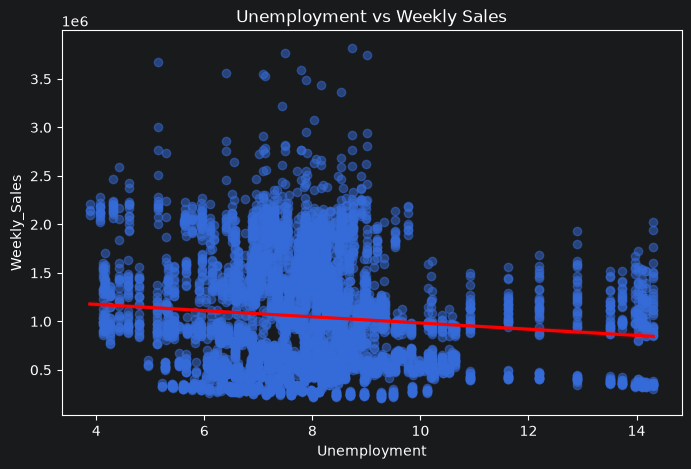

In [31]:
plt.figure(figsize=(8, 5))
sns.regplot(
    data = df,
    x = 'Unemployment',
    y = 'Weekly_Sales',
    scatter_kws={'alpha':0.5},
    line_kws= {'color':'red'}
)
plt.title('Unemployment vs Weekly Sales')
plt.savefig("images/Unemployment_vs_Weekly_Sales.png",dpi=300,bbox_inches='tight')
plt.show()

### Holiday vs Weekly Sales

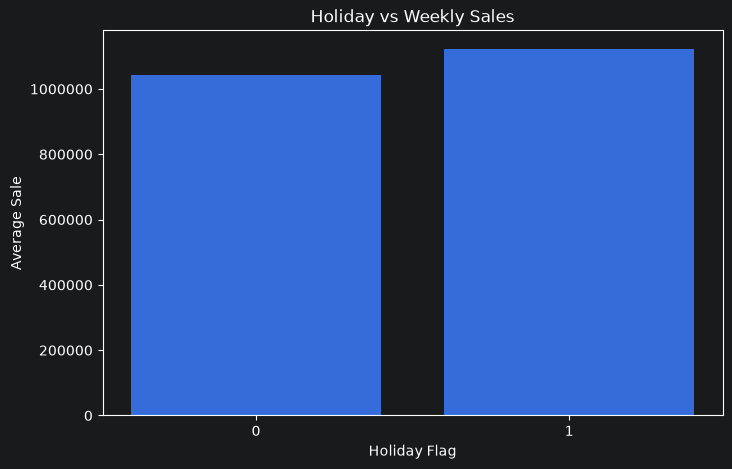

In [32]:
holiday_sales = df.groupby('Holiday_Flag')['Weekly_Sales'].mean()
plt.figure(figsize=(8,5))
plt.bar(
    holiday_sales.index.astype(str),
    holiday_sales.values
)
plt.title('Holiday vs Weekly Sales')
plt.xlabel('Holiday Flag')
plt.ylabel('Average Sale')

plt.ticklabel_format(style='plain',axis='y')
plt.savefig("images/Holiday_vs_Weekly_Sales.png",dpi=300,bbox_inches='tight')
plt.show()

### Monthly Sales Trend

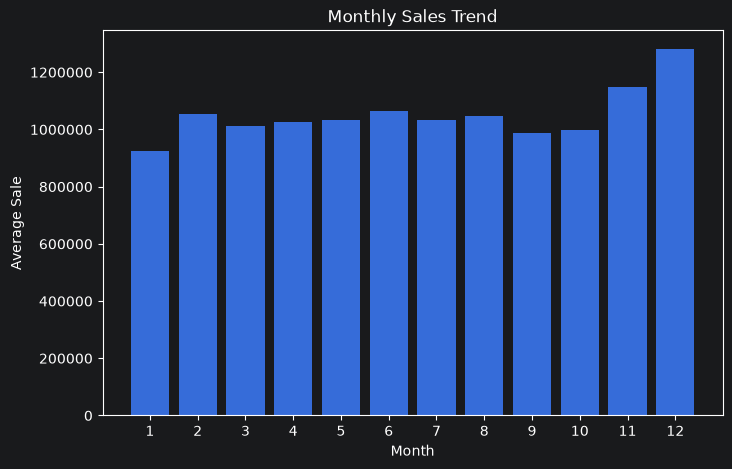

In [33]:
monthly_sales = df.groupby('Month')["Weekly_Sales"].mean()

plt.figure(figsize=(8,5))
plt.bar(
    monthly_sales.index.astype(str),
    monthly_sales.values,
)
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Average Sale')

plt.ticklabel_format(style='plain',axis='y')
plt.savefig("images/Monthly_Sales_Trend.png",dpi=300,bbox_inches='tight')
plt.show()

### Store Wise Sales

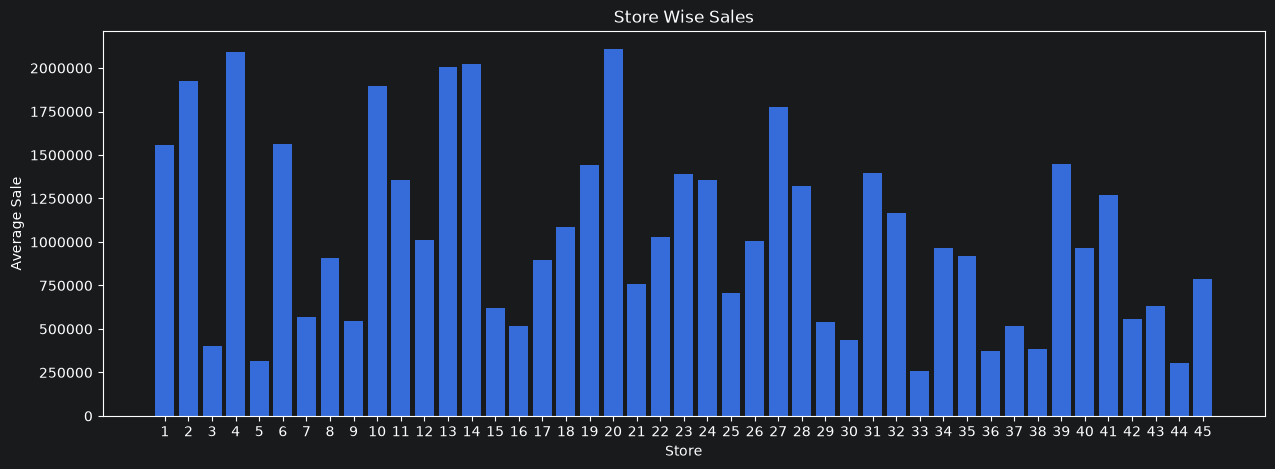

In [34]:
store_sales = df.groupby('Store')["Weekly_Sales"].mean()

plt.figure(figsize=(15,5))
plt.bar(
    store_sales.index.astype(str),
    store_sales.values
)
plt.title('Store Wise Sales')
plt.xlabel('Store')
plt.ylabel('Average Sale')

plt.ticklabel_format(style='plain',axis='y')
plt.savefig("images/Store_Wise_Sales.png",dpi=300,bbox_inches='tight')
plt.show()

## Heatmap

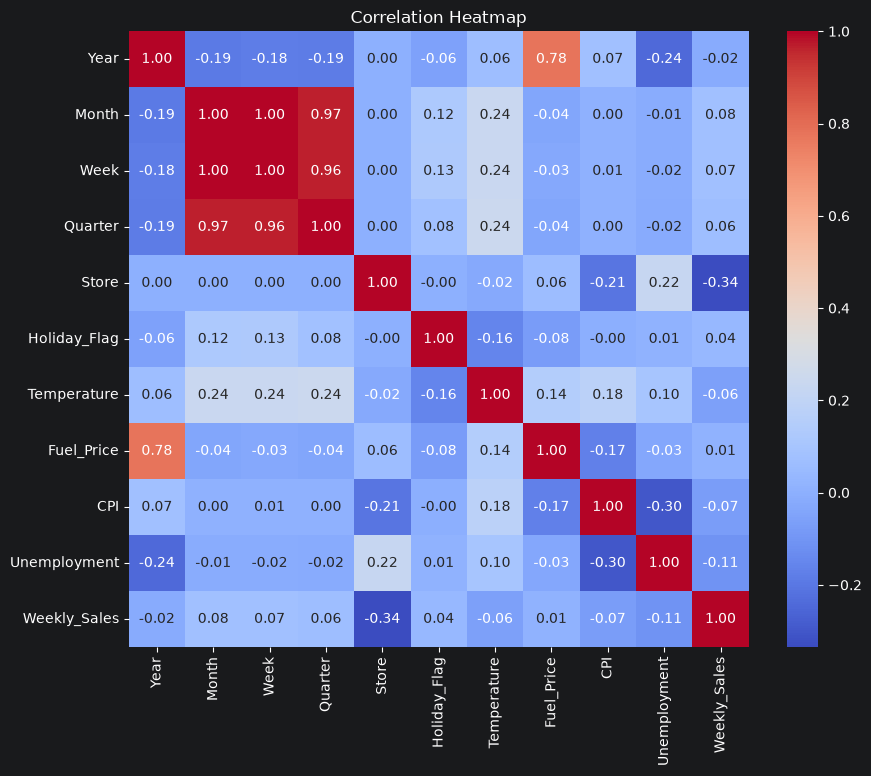

In [35]:
plt.figure(figsize=(10,8))
sns.heatmap(
    df.corr(),
    annot = True,
    cmap = 'coolwarm',
    fmt = '.2f'
)
plt.title('Correlation Heatmap')
plt.savefig("images/Heatmap.png",dpi=300,bbox_inches='tight')
plt.show()